<a href="https://colab.research.google.com/github/djcd171117/TERMINAL-III/blob/main/Evaluacion%201_Terminal%20de%20Economia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import os
import glob
import re
from google.colab import drive

# 1. Montar Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
ruta_carpeta = '/content/drive/MyDrive/ECONOMÍA CLASE/'

# 2. Buscar archivos
archivos_csv = glob.glob(os.path.join(ruta_carpeta, "financiamientos_*.csv"))
datasets = []

print(f"--- Iniciando consolidación de {len(archivos_csv)} archivos ---")

for ruta_completa in archivos_csv:
    nombre_archivo = os.path.basename(ruta_completa)

    # Leemos con latin-1 los archivos CSV
    try:
        df_temp = pd.read_csv(ruta_completa, encoding='latin-1', low_memory=False)
    except:
        df_temp = pd.read_csv(ruta_completa, encoding='utf-8-sig', low_memory=False)

    #Quitamos acentos y 'ñ' de las cabeceras para evitar el error
    df_temp.columns = df_temp.columns.str.lower().str.strip().str.replace(' ', '_')
    df_temp.columns = df_temp.columns.str.replace('ñ', 'n').str.replace('á', 'a').str.replace('é', 'e')

    # ESTANDARIZACIÓN DE CLAVES
    df_temp['cve_ent'] = pd.to_numeric(df_temp['cve_ent'], errors='coerce').astype('Int64').astype(str).str.zfill(2)
    df_temp['cve_mun'] = pd.to_numeric(df_temp['cve_mun'], errors='coerce').astype('Int64').astype(str).str.zfill(3)

    # FILTRO DE VIVIENDA NUEVA
    df_temp = df_temp[df_temp['destino'] == 2].copy()

    # BUSCAR LA COLUMNA DEL AÑO
    col_anio = [c for c in df_temp.columns if 'ano' in c or 'año' in c]

    if col_anio:
        df_temp['año_analisis'] = pd.to_numeric(df_temp[col_anio[0]], errors='coerce').astype('Int64')
    else:
        # Fallback: Extraer del nombre del archivo si la columna no existe
        anio_extraido = re.search(r'\d{4}', nombre_archivo)
        df_temp['año_analisis'] = int(anio_extraido.group()) if anio_extraido else 0

    datasets.append(df_temp)

# 3. Fusión y Limpieza
if datasets:
    df_historico = pd.concat(datasets, axis=0, ignore_index=True)
    df_historico['monto'] = pd.to_numeric(df_historico['monto'], errors='coerce').fillna(0)
    df_historico['acciones'] = pd.to_numeric(df_historico['acciones'], errors='coerce').fillna(0)

    # MASTER INTEGRADO
    ruta_salida = os.path.join(ruta_carpeta, 'master_historico_qro.csv')
    df_historico.to_csv(ruta_salida, index=False)
    print(f"\n--- ÉXITO: {df_historico.shape[0]} registros consolidados ---")
else:
    print("No se encontraron archivos válidos.")

--- Iniciando consolidación de 7 archivos ---

--- ÉXITO: 819583 registros consolidados ---


/tmp/ipykernel_9715/227880516.py:36: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  brecha = brecha.groupby('municipio', group_keys=False).apply(calcular_porcentaje_esfuerzo)


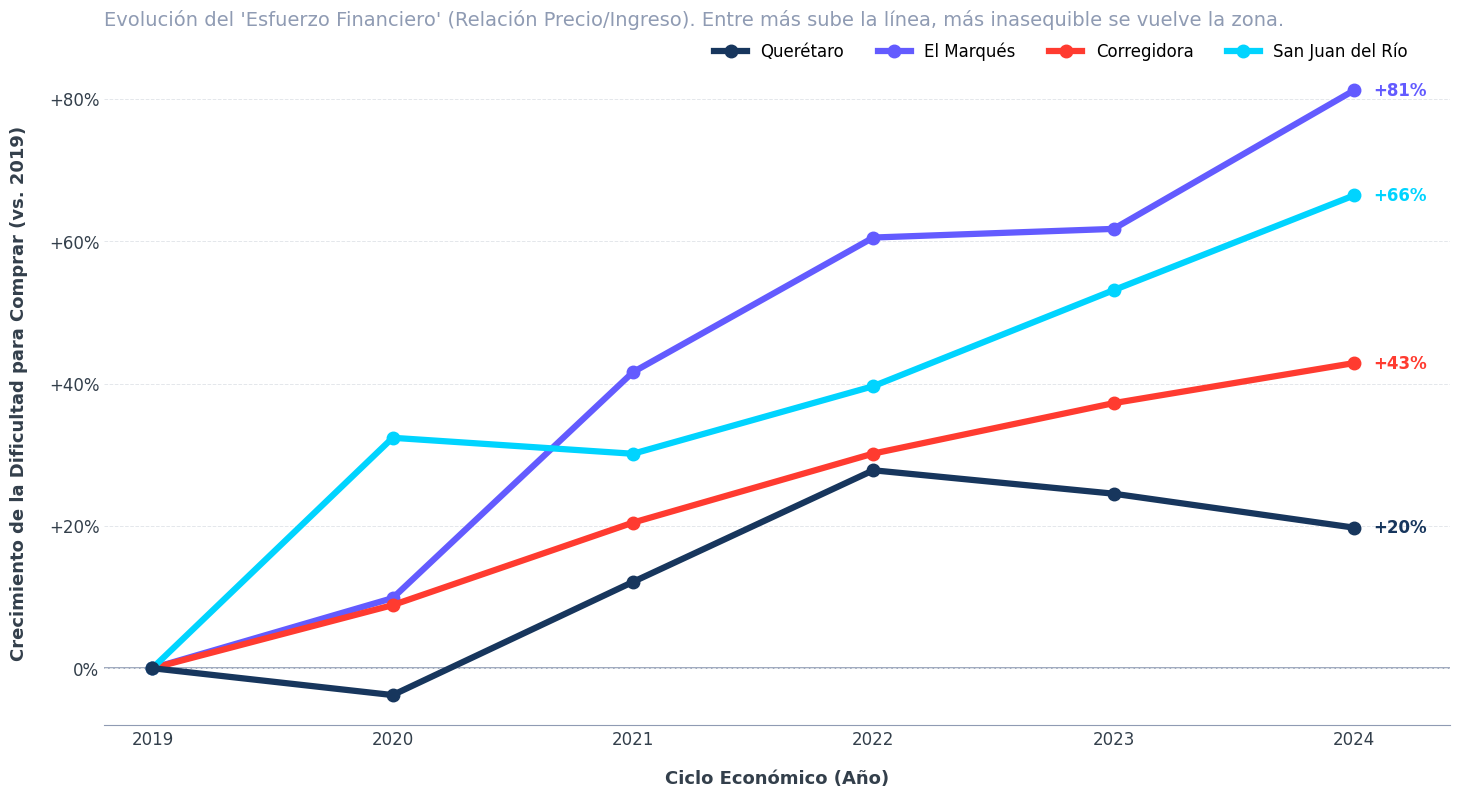

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ==============================================================================
# 1. PREPARACIÓN Y LIMPIEZA
# ==============================================================================
df_historico['cve_ent'] = pd.to_numeric(df_historico['cve_ent'], errors='coerce').fillna(0).astype(int).astype(str).str.zfill(2)
df_historico['cve_mun'] = pd.to_numeric(df_historico['cve_mun'], errors='coerce').fillna(0).astype(int).astype(str).str.zfill(3)

df_q = df_historico[df_historico['cve_ent'] == '22'].copy()
foco_codes = ['014', '011', '006', '016']
mapa_nombres = {'014': 'Querétaro', '011': 'El Marqués', '006': 'Corregidora', '016': 'San Juan del Río'}

brecha = df_q[df_q['cve_mun'].isin(foco_codes)].groupby(['año_analisis', 'cve_mun']).agg(
    precio_promedio=('monto', 'mean'),
    ingreso_promedio=('ingresos_rango', 'mean')
).reset_index()

# === CORRECCIÓN 1: ELIMINAR 2025 (AÑO INCOMPLETO) ===
brecha = brecha[brecha['año_analisis'] <= 2024]

brecha['municipio'] = brecha['cve_mun'].map(mapa_nombres)

# Ratio de esfuerzo
brecha['esfuerzo_absoluto'] = brecha['precio_promedio'] / brecha['ingreso_promedio']

# === CORRECCIÓN 2: DE "BASE 100" A "PORCENTAJE DE CRECIMIENTO" ===
def calcular_porcentaje_esfuerzo(group):
    # Tomamos el valor de 2019 como la base (0%)
    base_esfuerzo = group.loc[group['año_analisis'] == 2019, 'esfuerzo_absoluto'].values[0]
    # Calculamos cuánto creció porcentualmente respecto a 2019
    group['pct_crecimiento'] = ((group['esfuerzo_absoluto'] / base_esfuerzo) - 1) * 100
    return group

brecha = brecha.groupby('municipio', group_keys=False).apply(calcular_porcentaje_esfuerzo)

# ==============================================================================
# 2. VISUALIZACIÓN
# ==============================================================================
paleta_jerarquia = {
    'Querétaro': '#17365D',
    'El Marqués': '#635BFF',
    'Corregidora': '#FF3B30',
    'San Juan del Río': '#00D4FF'
}

plt.rcParams['font.family'] = 'sans-serif'
fig, ax = plt.subplots(figsize=(15, 8.5), facecolor='white')
ax.set_facecolor('white')

# Grid limpio
ax.grid(axis='y', color='#E4E7EB', linestyle='--', linewidth=0.7, zorder=0)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#8F9BB3')

# Línea Base 0% (Mucho más sutil y elegante)
ax.axhline(0, color='#8F9BB3', linewidth=1.2, linestyle='-', zorder=1)

# Graficado por municipio
for mun in ['Querétaro', 'El Marqués', 'Corregidora', 'San Juan del Río']:
    data = brecha[brecha['municipio'] == mun].sort_values('año_analisis')
    if data.empty: continue

    # Línea
    ax.plot(data['año_analisis'], data['pct_crecimiento'], marker='o', markersize=9, linewidth=4.5,
            label=mun, color=paleta_jerarquia[mun], zorder=4 if mun == 'Querétaro' else 3)

    # Etiqueta al final de la línea (+X%)
    ultimo_año = data['año_analisis'].iloc[-1]
    ultimo_val = data['pct_crecimiento'].iloc[-1]
    # Formateamos para que diga "+45%" o "-10%"
    signo = "+" if ultimo_val > 0 else ""
    ax.text(ultimo_año + 0.08, ultimo_val, f"{signo}{ultimo_val:.0f}%", color=paleta_jerarquia[mun], fontweight='bold', fontsize=12, va='center')

# Formato de Eje Y (Porcentajes)
def formato_pct(x, pos):
    if x == 0: return "0%"
    return f"+{x:.0f}%" if x > 0 else f"{x:.0f}%"
ax.yaxis.set_major_formatter(FuncFormatter(formato_pct))

ax.set_ylabel("Crecimiento de la Dificultad para Comprar (vs. 2019)", fontsize=13, fontweight='bold', color='#333F4B', labelpad=15)
ax.set_xlabel("Ciclo Económico (Año)", fontsize=13, fontweight='bold', color='#333F4B', labelpad=15)
ax.tick_params(axis='both', labelsize=12, colors='#333F4B', length=0)
ax.set_xticks(range(2019, 2025)) # Cortamos en 2024
ax.set_xlim(2018.8, 2024.4) # Ajuste de padding para las etiquetas finales

# Títulos sin el "plt.suptitle" porque ya va en la diapositiva
plt.title("Evolución del 'Esfuerzo Financiero' (Relación Precio/Ingreso). Entre más sube la línea, más inasequible se vuelve la zona.",
          fontsize=14, color='#8F9BB3', loc='left', pad=25)

plt.legend(bbox_to_anchor=(0.98, 1.05), loc='upper right', frameon=False, fontsize=12, ncol=4)

plt.tight_layout(rect=[0, 0, 0.98, 0.95])
plt.savefig('esfuerzo_financiero_porcentaje_16_9.png', dpi=300, bbox_inches='tight')
plt.show()

In [15]:
# Auditoría de meses por año
auditoria = df_historico.groupby('año_analisis').agg(
    meses_registrados=('mes', 'nunique'),
    ultimo_mes=('mes', 'max'),
    total_acciones=('acciones', 'sum')
).reset_index()

print("--- REVISIÓN DE INTEGRIDAD TEMPORAL ---")
print(auditoria.to_string(index=False))

--- REVISIÓN DE INTEGRIDAD TEMPORAL ---
 año_analisis  meses_registrados  ultimo_mes  total_acciones
         2019                 12          12        315384.0
         2020                 12          12        298744.0
         2021                 12          12        284560.0
         2022                 12          12        278244.0
         2023                 12          12        247909.0
         2024                 12          12        249510.0
         2025                 11          11        208463.0


In [16]:
# 1. Filtramos para quedarnos solo con los ENEROS de cada año
df_eneros = df_historico[df_historico['mes'] == 1].copy()

# 2. Agrupamos para ver la tendencia real de arranque de año en Querétaro (Entidad 22)
tendencia_enero = df_eneros[df_eneros['cve_ent'] == '22'].groupby('año_analisis').agg(
    acciones_enero=('acciones', 'sum'),
    capital_enero=('monto', 'sum'),
    ticket_enero=('monto', 'mean')
).reset_index()

# 3. Calculamos la variación porcentual respecto al año anterior
tendencia_enero['crecimiento_volumen'] = tendencia_enero['acciones_enero'].pct_change() * 100

print("--- COMPARATIVA ESTRATÉGICA: ENERO 2019 VS ENERO 2025 ---")
print(tendencia_enero.to_string(index=False))

--- COMPARATIVA ESTRATÉGICA: ENERO 2019 VS ENERO 2025 ---
 año_analisis  acciones_enero  capital_enero  ticket_enero  crecimiento_volumen
         2019           700.0   6.357482e+08  1.704419e+06                  NaN
         2020           843.0   7.784122e+08  1.990824e+06            20.428571
         2021           720.0   7.114617e+08  1.922869e+06           -14.590747
         2022           737.0   8.244792e+08  2.258847e+06             2.361111
         2023           690.0   8.775900e+08  2.651329e+06            -6.377205
         2024           911.0   1.150572e+09  2.833921e+06            32.028986
         2025           382.0   5.302050e+08  2.335705e+06           -58.068057


In [17]:
# 1. Filtramos solo los meses de enero de toda la historia
df_eneros = df_historico[df_historico['mes'] == 1].copy()

# 2. Agrupamos por año para Querétaro (Entidad 22)
# Queremos ver si el 'músculo' de enero de 2025 es más fuerte o débil que los anteriores
comparativa_eneros = df_eneros[df_eneros['cve_ent'] == '22'].groupby('año_analisis').agg(
    acciones_enero=('acciones', 'sum'),
    capital_enero=('monto', 'sum'),
    ticket_promedio_enero=('monto', 'mean')
).reset_index()

# 3. Calculamos el crecimiento del Ticket Promedio respecto al Enero anterior
comparativa_eneros['var_ticket_pct'] = comparativa_eneros['ticket_promedio_enero'].pct_change() * 100

print("--- DIAGNÓSTICO ESTRATÉGICO: TENDENCIA DE ARRANQUE (2019-2025) ---")
print(comparativa_eneros.to_string(index=False))

--- DIAGNÓSTICO ESTRATÉGICO: TENDENCIA DE ARRANQUE (2019-2025) ---
 año_analisis  acciones_enero  capital_enero  ticket_promedio_enero  var_ticket_pct
         2019           700.0   6.357482e+08           1.704419e+06             NaN
         2020           843.0   7.784122e+08           1.990824e+06       16.803703
         2021           720.0   7.114617e+08           1.922869e+06       -3.413397
         2022           737.0   8.244792e+08           2.258847e+06       17.472722
         2023           690.0   8.775900e+08           2.651329e+06       17.375331
         2024           911.0   1.150572e+09           2.833921e+06        6.886789
         2025           382.0   5.302050e+08           2.335705e+06      -17.580446


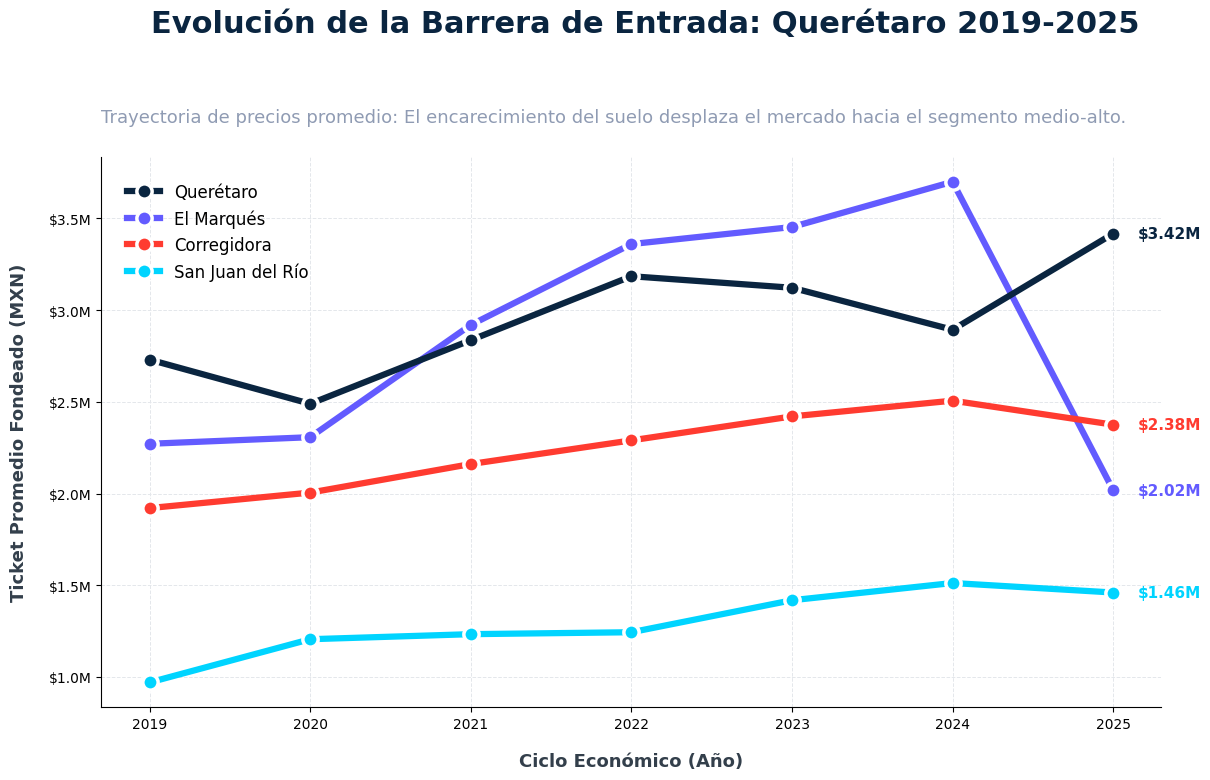

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ==============================================================================
# 1. CARGA Y LIMPIEZA ROBUSTA
# ==============================================================================
ruta_master = '/content/drive/MyDrive/ECONOMÍA CLASE/master_historico_qro.csv'
df_hist = pd.read_csv(ruta_master, low_memory=False)

# Limpieza agresiva de claves (manejando nulos, enteros, y zfill)
df_hist['cve_ent'] = pd.to_numeric(df_hist['cve_ent'], errors='coerce').fillna(0).astype(int).astype(str).str.zfill(2)
df_hist['cve_mun'] = pd.to_numeric(df_hist['cve_mun'], errors='coerce').fillna(0).astype(int).astype(str).str.zfill(3)

# Filtramos solo Querétaro (Entidad 22)
df_q = df_hist[df_hist['cve_ent'] == '22'].copy()

# Mapeo de códigos con la jerarquía
foco_codes = ['014', '011', '006', '016']
mapa_nombres = {'014': 'Querétaro', '011': 'El Marqués', '006': 'Corregidora', '016': 'San Juan del Río'}

# Agrupación por Año y Municipio (Metric: Ticket Promedio)
historico = df_q[df_q['cve_mun'].isin(foco_codes)].groupby(['año_analisis', 'cve_mun']).agg(
    ticket_promedio=('monto', 'mean')
).reset_index()

# Mapeo final: Ahora 'cve_mun' sí coincidirá perfectamente
historico['municipio_nombre'] = historico['cve_mun'].map(mapa_nombres)

# ==============================================================================
# 2. VISUALIZACIÓN PREMIUM (Estilo Consultoría)
# ==============================================================================
paleta_jerarquia = {
    'Querétaro': '#0A2540',      # Navy: Autoridad y mercado ancla
    'El Marqués': '#635BFF',     # Morado: Crecimiento y absorción industrial
    'Corregidora': '#FF3B30',    # Rojo: Alerta de Precio / Segmento Residencial
    'San Juan del Río': '#00D4FF' # Cyan: Base de la pirámide y volumen
}

plt.rcParams['font.family'] = 'sans-serif'
fig, ax = plt.subplots(figsize=(13, 8), facecolor='white')
ax.set_facecolor('white')
ax.grid(color='#E4E7EB', linestyle='--', linewidth=0.7, zorder=0)

# Graficamos siguiendo el orden de jerarquía
for mun in ['Querétaro', 'El Marqués', 'Corregidora', 'San Juan del Río']:
    data = historico[historico['municipio_nombre'] == mun].sort_values('año_analisis')

    if data.empty:
        continue

    # Línea con grosor premium y marcadores
    ax.plot(data['año_analisis'], data['ticket_promedio'],
            color=paleta_jerarquia[mun], linewidth=4.5, marker='o',
            markersize=11, markeredgecolor='white', markeredgewidth=2.5,
            label=mun, zorder=5 if mun == 'Querétaro' else 3)

    # Etiqueta de valor final a la derecha del último punto
    ultimo_año = data['año_analisis'].iloc[-1]
    ultimo_val = data['ticket_promedio'].iloc[-1]
    ax.text(ultimo_año + 0.15, ultimo_val, f"${ultimo_val/1e6:.2f}M",
            color=paleta_jerarquia[mun], fontweight='bold', va='center', fontsize=11)

# Formatos de Ejes
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"${x/1e6:,.1f}M"))
ax.set_xticks(range(2019, 2026))
ax.set_xlabel("Ciclo Económico (Año)", fontsize=13, fontweight='bold', color='#333F4B', labelpad=15)
ax.set_ylabel("Ticket Promedio Fondeado (MXN)", fontsize=13, fontweight='bold', color='#333F4B', labelpad=15)

# Títulos
plt.suptitle('Evolución de la Barrera de Entrada: Querétaro 2019-2025',
             fontsize=22, fontweight='bold', color='#0A2540', x=0.12, ha='left', y=0.97)
plt.title('Trayectoria de precios promedio: El encarecimiento del suelo desplaza el mercado hacia el segmento medio-alto.',
          fontsize=13, color='#8F9BB3', loc='left', pad=25)

# Limpieza de bordes y leyenda
for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.legend(frameon=False, loc='upper left', fontsize=12, bbox_to_anchor=(0.01, 0.98))

plt.tight_layout(rect=[0, 0, 0.94, 0.92])

# Exportar e Imprimir
plt.savefig('trayectoria_historica_premium.png', dpi=300, bbox_inches='tight')
plt.show()

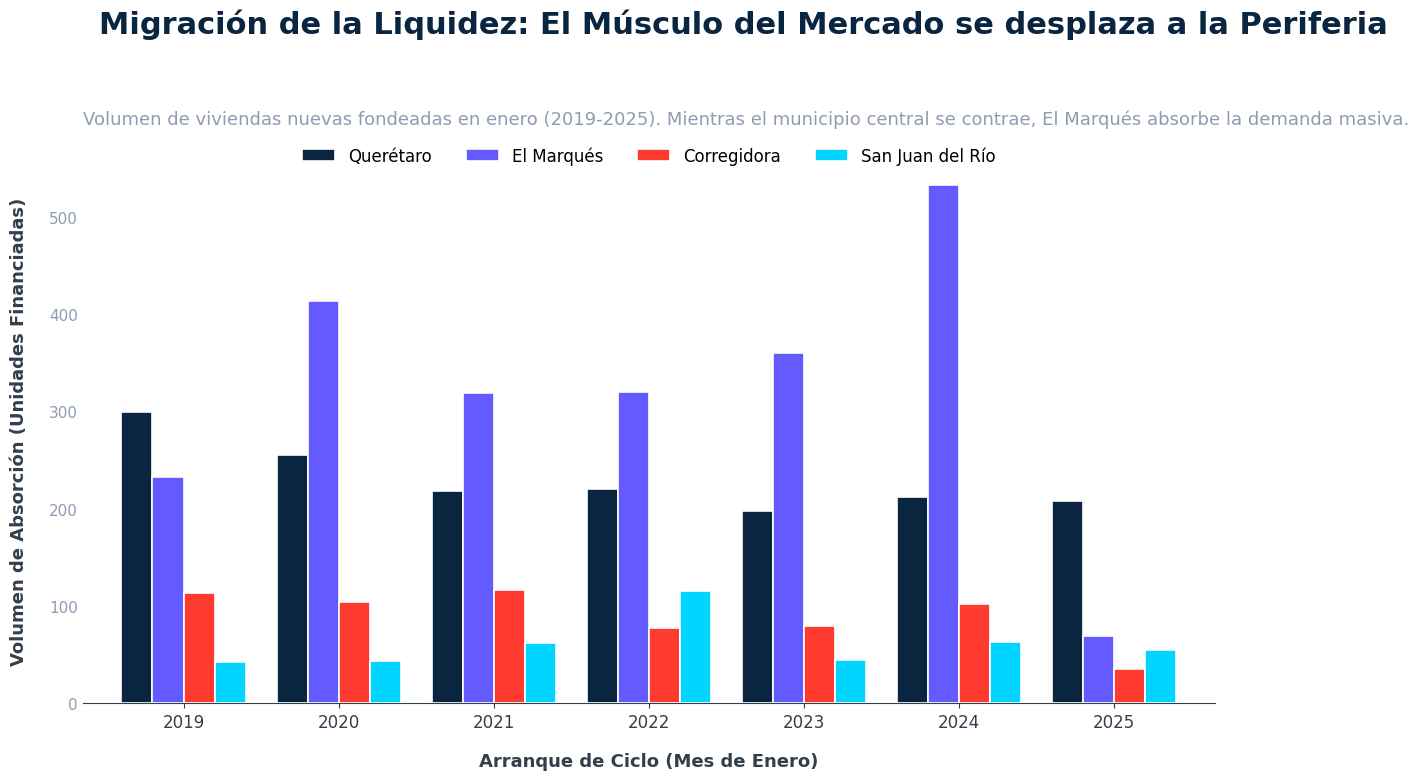

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. CARGA, LIMPIEZA Y FILTRADO ESTRATÉGICO ("SOLO ENEROS")
# ==============================================================================
ruta_master = '/content/drive/MyDrive/ECONOMÍA CLASE/master_historico_qro.csv'
df_hist = pd.read_csv(ruta_master, low_memory=False)

# Limpieza robusta de claves
df_hist['cve_ent'] = pd.to_numeric(df_hist['cve_ent'], errors='coerce').fillna(0).astype(int).astype(str).str.zfill(2)
df_hist['cve_mun'] = pd.to_numeric(df_hist['cve_mun'], errors='coerce').fillna(0).astype(int).astype(str).str.zfill(3)

# Limpieza de la métrica de volumen
df_hist['acciones'] = pd.to_numeric(df_hist['acciones'], errors='coerce').fillna(0)

# FILTRO CLAVE: Solo Querétaro (22) y SOLO el mes de Enero (1) para ver el arranque real
df_q = df_hist[(df_hist['cve_ent'] == '22') & (df_hist['mes'] == 1)].copy()

# Mapeo de jerarquía
foco_codes = ['014', '011', '006', '016']
mapa_nombres = {'014': 'Querétaro', '011': 'El Marqués', '006': 'Corregidora', '016': 'San Juan del Río'}

# Agrupación de Volumen (Suma de acciones)
historico_vol = df_q[df_q['cve_mun'].isin(foco_codes)].groupby(['año_analisis', 'cve_mun']).agg(
    volumen_casas=('acciones', 'sum')
).reset_index()

historico_vol['municipio_nombre'] = historico_vol['cve_mun'].map(mapa_nombres)

# Pivotamos la tabla para que sea fácil graficar barras agrupadas por año
df_pivot = historico_vol.pivot(index='año_analisis', columns='municipio_nombre', values='volumen_casas').fillna(0)

# Ordenamos las columnas según la jerarquía de la presentación
orden = ['Querétaro', 'El Marqués', 'Corregidora', 'San Juan del Río']
df_pivot = df_pivot[orden]

# ==============================================================================
# 2. VISUALIZACIÓN PREMIUM (Estilo Pitch Deck - Barras Agrupadas)
# ==============================================================================
paleta_jerarquia = {
    'Querétaro': '#0A2540',      # Navy
    'El Marqués': '#635BFF',     # Morado
    'Corregidora': '#FF3B30',    # Rojo
    'San Juan del Río': '#00D4FF' # Cyan
}
colores_lista = [paleta_jerarquia[m] for m in orden]

plt.rcParams['font.family'] = 'sans-serif'
fig, ax = plt.subplots(figsize=(13, 8), facecolor='white')
ax.set_facecolor('white')

# Grid solo horizontal para no ensuciar las barras
ax.grid(axis='y', color='#E4E7EB', linestyle='--', linewidth=0.7, zorder=0)

# Generación de las barras (Pandas interactúa directo con Matplotlib aquí)
df_pivot.plot(kind='bar', color=colores_lista, ax=ax, width=0.8, zorder=3, edgecolor='white', linewidth=1.2)

# Formato de Ejes y Bordes (Minimalismo)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#333F4B')

ax.tick_params(axis='y', length=0, labelsize=11, colors='#8F9BB3')
ax.tick_params(axis='x', rotation=0, labelsize=12, colors='#333F4B')

ax.set_xlabel("Arranque de Ciclo (Mes de Enero)", fontsize=13, fontweight='bold', color='#333F4B', labelpad=15)
ax.set_ylabel("Volumen de Absorción (Unidades Financiadas)", fontsize=13, fontweight='bold', color='#333F4B', labelpad=15)

# Títulos Directivos
plt.suptitle('Migración de la Liquidez: El Músculo del Mercado se desplaza a la Periferia',
             fontsize=22, fontweight='bold', color='#0A2540', x=0.08, ha='left', y=0.97)
plt.title('Volumen de viviendas nuevas fondeadas en enero (2019-2025). Mientras el municipio central se contrae, El Marqués absorbe la demanda masiva.',
          fontsize=13, color='#8F9BB3', loc='left', pad=25)

# Ajuste de Leyenda para que quede en una sola línea superior
plt.legend(frameon=False, loc='upper center', fontsize=12, bbox_to_anchor=(0.5, 1.05), ncol=4)

plt.tight_layout(rect=[0, 0, 0.95, 0.92])

# Exportar
plt.savefig('volumen_absorcion_barras.png', dpi=300, bbox_inches='tight')
plt.show()

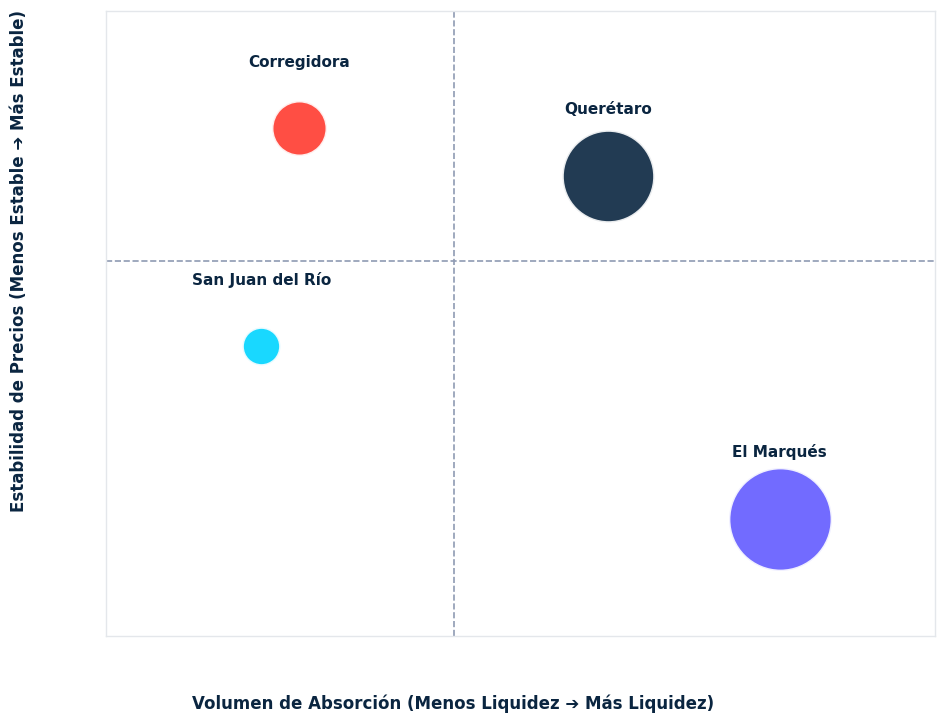

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================================================================
# 1. CARGA Y LIMPIEZA DE DATOS (Sin cambios)
# ==============================================================================
ruta_master = '/content/drive/MyDrive/ECONOMÍA CLASE/master_historico_qro.csv'
df_hist = pd.read_csv(ruta_master, low_memory=False)

df_hist['cve_ent'] = pd.to_numeric(df_hist['cve_ent'], errors='coerce').fillna(0).astype(int).astype(str).str.zfill(2)
df_hist['cve_mun'] = pd.to_numeric(df_hist['cve_mun'], errors='coerce').fillna(0).astype(int).astype(str).str.zfill(3)

df_q = df_hist[df_hist['cve_ent'] == '22'].copy()
df_q['monto'] = pd.to_numeric(df_q['monto'], errors='coerce').fillna(0)
df_q['acciones'] = pd.to_numeric(df_q['acciones'], errors='coerce').fillna(0)

foco_codes = ['014', '011', '006', '016']
mapa_nombres = {'014': 'Querétaro', '011': 'El Marqués', '006': 'Corregidora', '016': 'San Juan del Río'}

# ==============================================================================
# 2. CÁLCULO DE MÉTRICAS ESTRATÉGICAS (Sin cambios)
# ==============================================================================
anual = df_q[df_q['cve_mun'].isin(foco_codes)].groupby(['año_analisis', 'cve_mun']).agg(
    ticket_promedio=('monto', 'mean'),
    acciones_totales=('acciones', 'sum'),
    monto_total=('monto', 'sum')
).reset_index()

matriz_data = anual.groupby('cve_mun').agg(
    volumen_absorcion=('acciones_totales', 'mean'),
    ticket_mean=('ticket_promedio', 'mean'),
    ticket_std=('ticket_promedio', 'std'),
    tamaño_mercado=('monto_total', 'sum')
).reset_index()

matriz_data['estabilidad_precio'] = matriz_data['ticket_mean'] / matriz_data['ticket_std']
matriz_data['municipio'] = matriz_data['cve_mun'].map(mapa_nombres)

# ==============================================================================
# 3. VISUALIZACIÓN PREMIUM: SIMETRÍA Y CONTORNO
# ==============================================================================
paleta_jerarquia = {
    'Querétaro': '#0A2540',
    'El Marqués': '#635BFF',
    'Corregidora': '#FF3B30',
    'San Juan del Río': '#00D4FF'
}

# Configuramos un tamaño de figura ligeramente más cuadrado para mayor simetría
plt.rcParams['font.family'] = 'sans-serif'
fig, ax = plt.subplots(figsize=(10, 8), facecolor='white') # Tamaño más compacto
ax.set_facecolor('white')

# === EL SECRETO: EL CONTORNO (FRAME) ===
# Dibujamos un marco elegante alrededor del área de datos
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color('#E4E7EB') # Gris claro de tu paleta
    ax.spines[spine].set_linewidth(1.0) # Grosor sutil

# Ticks y etiquetas de ejes se mantienen ocultos (minimalismo)
ax.set_xticks([])
ax.set_yticks([])

# Medianas para cruzar los ejes (zorder bajo)
x_mid = matriz_data['volumen_absorcion'].median()
y_mid = matriz_data['estabilidad_precio'].median()

ax.axhline(y_mid, color='#8F9BB3', linestyle='--', linewidth=1.2, zorder=1)
ax.axvline(x_mid, color='#8F9BB3', linestyle='--', linewidth=1.2, zorder=1)

# === PADDING DINÁMICO REAJUSTADO (Tighter) ===
# Calculamos la distancia total de los datos y agregamos 30% de margen para contener las burbujas
x_range = matriz_data['volumen_absorcion'].max() - matriz_data['volumen_absorcion'].min()
y_range = matriz_data['estabilidad_precio'].max() - matriz_data['estabilidad_precio'].min()

# Padding de 30% para mayor contención
ax.set_xlim(matriz_data['volumen_absorcion'].min() - (x_range * 0.30),
            matriz_data['volumen_absorcion'].max() + (x_range * 0.30))
ax.set_ylim(matriz_data['estabilidad_precio'].min() - (y_range * 0.30),
            matriz_data['estabilidad_precio'].max() + (y_range * 0.30))

# Graficar las burbujas y etiquetas (zorder alto)
for _, row in matriz_data.iterrows():
    mun = row['municipio']
    # Aumentamos ligeramente el multiplicador para llenar el espacio framed
    bubble_size = (row['tamaño_mercado'] / matriz_data['tamaño_mercado'].max()) * 5500

    # Burbuja
    ax.scatter(row['volumen_absorcion'], row['estabilidad_precio'],
               s=bubble_size, color=paleta_jerarquia[mun], alpha=0.9,
               edgecolors='white', linewidth=2, zorder=3)

    # Nombre del municipio (Posicionado dinámicamente arriba de la burbuja con zorder alto)
    ax.text(row['volumen_absorcion'], row['estabilidad_precio'] + (y_range * 0.15),
            mun, color='#0A2540', fontweight='bold', fontsize=11,
            ha='center', va='bottom', zorder=4)

# === ETIQUETAS DE EJES DESCRIPTIVAS (Positioning alrededor del Box) ===
# En lugar de "Alta Liquidez ➔", usaremos descripciones claras como etiquetas de eje tradicionales,
# pero ancladas en el centro de los bordes externos del cuadro para mayor simetría visual.
# Usamos ax.annotate para posicionar texto relativo al centro del eje.

# Eje X: Volumen
ax.text(x_mid, ax.get_ylim()[0] - (y_range * 0.15),
        "Volumen de Absorción (Menos Liquidez ➔ Más Liquidez)",
        color='#0A2540', fontweight='bold', fontsize=12, ha='center', va='top')

# Eje Y: Estabilidad (Rotado)
ax.text(ax.get_xlim()[0] - (x_range * 0.15), y_mid,
        "Estabilidad de Precios (Menos Estable ➔ Más Estable)",
        color='#0A2540', fontweight='bold', fontsize=12, ha='right', va='center', rotation=90)


# === ELIMINACIÓN DEL TÍTULO PRINCIPAL (Para evitar redundancia en diapositiva) ===
# ¡PLT.SUPTITLE ELIMINADO!

# Ajuste de Layout
plt.tight_layout(rect=[0, 0, 0.95, 0.92])

# Exportar
plt.savefig('matriz_decision_framed_premium.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_9715/12461933.py:100: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


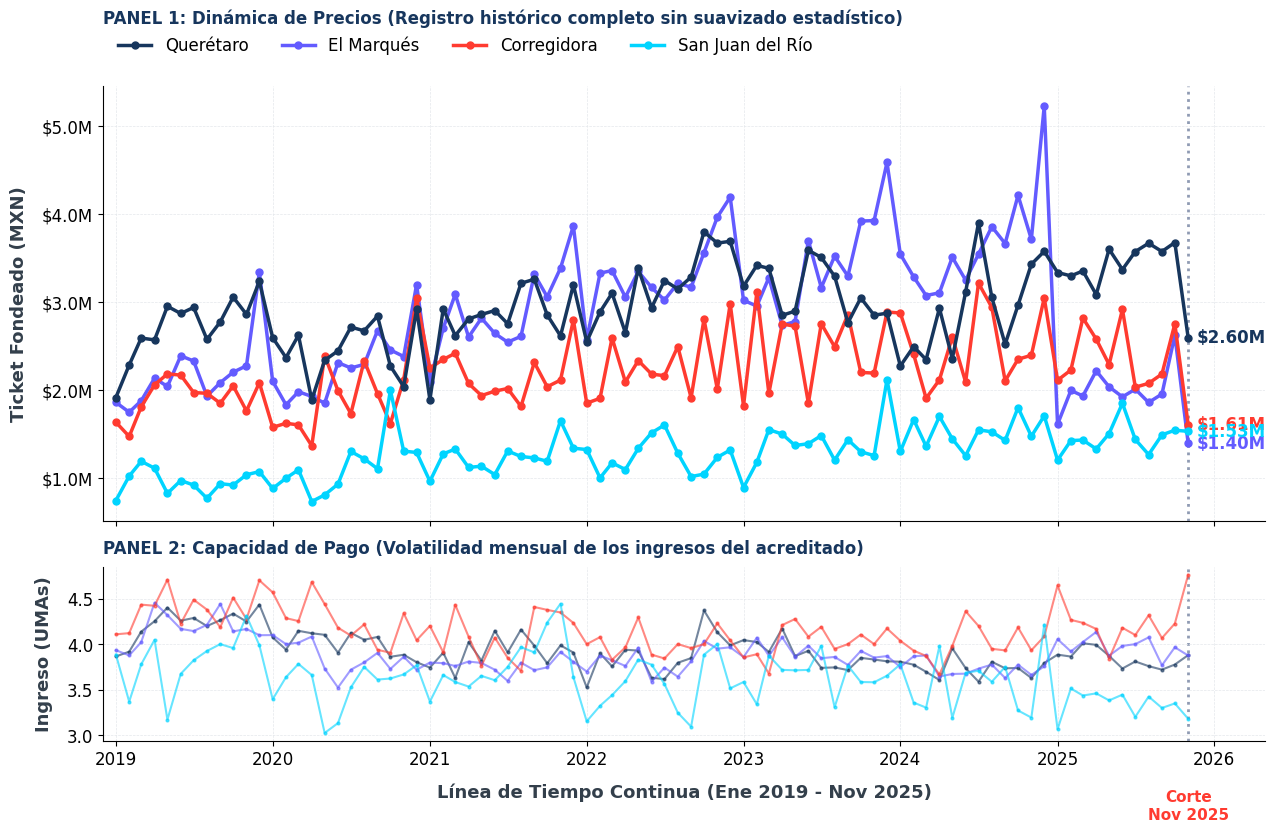

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates

# ==============================================================================
# 1. CARGA DE DATOS
# ==============================================================================
ruta_master = '/content/drive/MyDrive/ECONOMÍA CLASE/master_historico_qro.csv'
df_hist = pd.read_csv(ruta_master, low_memory=False)

df_hist['cve_ent'] = pd.to_numeric(df_hist['cve_ent'], errors='coerce')
df_hist['cve_mun'] = pd.to_numeric(df_hist['cve_mun'], errors='coerce')

df_q = df_hist[df_hist['cve_ent'] == 22].copy()
df_q['fecha'] = pd.to_datetime(df_q['año_analisis'].astype(str) + '-' + df_q['mes'].astype(str).str.zfill(2) + '-01', errors='coerce')
df_q = df_q.dropna(subset=['fecha'])

foco_codes = [14, 11, 6, 16]
mapa_nombres = {14: 'Querétaro', 11: 'El Marqués', 6: 'Corregidora', 16: 'San Juan del Río'}

historico = df_q[df_q['cve_mun'].isin(foco_codes)].groupby(['fecha', 'cve_mun']).agg(
    ticket_promedio=('monto', 'mean'),
    ingreso_promedio=('ingresos_rango', 'mean')
).reset_index()

historico['municipio_nombre'] = historico['cve_mun'].map(mapa_nombres)

# ==============================================================================
# 2. VISUALIZACIÓN PANORÁMICA 16:9 (Corrección de Leyenda)
# ==============================================================================
paleta_jerarquia = {
    'Querétaro': '#17365D',  # True Navy
    'El Marqués': '#635BFF',
    'Corregidora': '#FF3B30',
    'San Juan del Río': '#00D4FF'
}

plt.rcParams['font.family'] = 'sans-serif'
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8.5), sharex=True, gridspec_kw={'height_ratios': [2.5, 1], 'hspace': 0.15})
fig.patch.set_facecolor('white')

for ax in [ax1, ax2]:
    ax.set_facecolor('white')
    ax.grid(color='#E4E7EB', linestyle='--', linewidth=0.5, zorder=0)
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)

ultima_fecha = historico['fecha'].max()

# --- PANEL 1: PRECIOS ---
for mun in ['Querétaro', 'El Marqués', 'Corregidora', 'San Juan del Río']:
    data = historico[historico['municipio_nombre'] == mun].sort_values('fecha')
    if data.empty: continue

    ax1.plot(data['fecha'], data['ticket_promedio'], color=paleta_jerarquia[mun],
             linewidth=2.5, marker='o', markersize=5, label=mun, zorder=5 if mun == 'Querétaro' else 3)

    ultimo_val = data['ticket_promedio'].iloc[-1]
    ax1.text(ultima_fecha + pd.Timedelta(days=20), ultimo_val, f"${ultimo_val/1e6:.2f}M",
             color=paleta_jerarquia[mun], fontweight='bold', va='center', fontsize=12)

ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"${x/1e6:,.1f}M"))
ax1.set_ylabel("Ticket Fondeado (MXN)", fontsize=13, fontweight='bold', color='#333F4B', labelpad=10)
ax1.tick_params(axis='y', labelsize=12)

# === LA SOLUCIÓN DEL SOLAPAMIENTO ===
# 1. Empujamos el título muy arriba (pad=45)
ax1.set_title('PANEL 1: Dinámica de Precios (Registro histórico completo sin suavizado estadístico)',
              fontsize=12, color='#17365D', fontweight='bold', loc='left', pad=45)

# 2. Colocamos la leyenda en medio, flotando limpia sin marco (frameon=False)
leg = ax1.legend(frameon=False, loc='upper left', fontsize=12, ncol=4, bbox_to_anchor=(0, 1.15))
# =====================================

# --- PANEL 2: INGRESOS ---
for mun in ['Querétaro', 'El Marqués', 'Corregidora', 'San Juan del Río']:
    data = historico[historico['municipio_nombre'] == mun].sort_values('fecha')
    if data.empty: continue
    ax2.plot(data['fecha'], data['ingreso_promedio'], color=paleta_jerarquia[mun],
             linewidth=1.5, linestyle='-', marker='.', markersize=4, alpha=0.6, zorder=3)

ax2.set_ylabel("Ingreso (UMAs)", fontsize=13, fontweight='bold', color='#333F4B', labelpad=10)
ax2.xaxis.set_major_locator(mdates.YearLocator())
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.set_xlabel("Línea de Tiempo Continua (Ene 2019 - Nov 2025)", fontsize=13, fontweight='bold', color='#333F4B', labelpad=10)
ax2.tick_params(axis='both', labelsize=12)
ax2.set_title('PANEL 2: Capacidad de Pago (Volatilidad mensual de los ingresos del acreditado)',
              fontsize=12, color='#17365D', fontweight='bold', loc='left', pad=10)

# --- LÍNEA DE CORTE ---
for ax in [ax1, ax2]:
    ax.axvline(ultima_fecha, color='#8F9BB3', linestyle=':', linewidth=2, zorder=1)

ax2.text(ultima_fecha, ax2.get_ylim()[0] - (ax2.get_ylim()[1]-ax2.get_ylim()[0])*0.28,
         "Corte\nNov 2025", color='#FF3B30', fontweight='bold', fontsize=11, ha='center', va='top')

# Padding dinámico en el eje X para que los textos de $X.XXM no se corten
ax1.set_xlim(historico['fecha'].min() - pd.Timedelta(days=30), ultima_fecha + pd.Timedelta(days=180))

plt.tight_layout()
plt.savefig('panel_tiempo_panoramico_final.png', dpi=300, bbox_inches='tight')
plt.show()